<a href="https://colab.research.google.com/github/Sowmya74/DNSC_6330_Responsible_Machine_Learning/blob/main/Individual_Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Individual Assignment 1: Translating the Lecture 01 R Workflow into Python**

This notebook reproduces the COMPAS recidivism analysis originally implemented in R. The purpose is to recreate the full workflow in Python, including data cleaning, exploratory analysis, logistic regression, and fairness diagnostics.

In [ ]:
#Imports
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.metrics import confusion_matrix

## Load the COMPAS Dataset

The first step is to load the COMPAS recidivism dataset from the ProPublica repository and inspect its structure. The original dataset contains 7,214 defendants.

In [ ]:
# Load the COMPAS dataset

url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"

raw_data = pd.read_csv(url)

# Equivalent of nrow(raw_data)
print(len(raw_data))

7214


In [ ]:
# Equivalent of head(raw_data, 10)
print(raw_data.head(10))

   id                name      first         last compas_screening_date  \
0   1    miguel hernandez     miguel    hernandez            2013-08-14   
1   3         kevon dixon      kevon        dixon            2013-01-27   
2   4            ed philo         ed        philo            2013-04-14   
3   5         marcu brown      marcu        brown            2013-01-13   
4   6  bouthy pierrelouis     bouthy  pierrelouis            2013-03-26   
5   7        marsha miles     marsha        miles            2013-11-30   
6   8       edward riddle     edward       riddle            2014-02-19   
7   9      steven stewart     steven      stewart            2013-08-30   
8  10    elizabeth thieme  elizabeth       thieme            2014-03-16   
9  13           bo bradac         bo       bradac            2013-11-04   

      sex         dob  age          age_cat              race  ...  \
0    Male  1947-04-18   69  Greater than 45             Other  ...   
1    Male  1982-01-22   34        

## Select Variables and Applying the filters

The original R workflow uses only the variables needed for the analysis. The data are filtered to remove:

- observations where the COMPAS screening occurred more than 30 days from arrest
- observations with missing recidivism information
- ordinary traffic charges
- observations with missing COMPAS scores

After filtering, the final analytical sample contains 6,172 defendants.

## Convert Variables to the Appropriate Data Types

The jail entry and exit variables are converted to datetime format. Categorical variables are converted to factors

- Reference race: Caucasian
- Reference age category: 25–45
- Reference sex: Male
- Reference charge degree: Felony


In [ ]:
# ------------------------------------------------------------
# Numeric and Datetime Variables
# ------------------------------------------------------------

numeric_vars = [
    "age",
    "priors_count",
    "days_b_screening_arrest",
    "decile_score"
]

datetime_vars = [
    "c_jail_in",
    "c_jail_out"
]

# ------------------------------------------------------------
# Select only required columns
# ------------------------------------------------------------

df = raw_data[
    [
        "age",
        "c_charge_degree",
        "race",
        "age_cat",
        "score_text",
        "sex",
        "priors_count",
        "days_b_screening_arrest",
        "decile_score",
        "is_recid",
        "two_year_recid",
        "c_jail_in",
        "c_jail_out"
    ]
].copy()

# ------------------------------------------------------------
# Filtering
# ------------------------------------------------------------

df = df[
    (df["days_b_screening_arrest"] >= -30) &
    (df["days_b_screening_arrest"] <= 30)
]

df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"]

# ------------------------------------------------------------
# Type conversions
# ------------------------------------------------------------

for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], errors="coerce")

for col in df.columns:
    if col not in numeric_vars + datetime_vars:
        df[col] = df[col].astype("category")

# ------------------------------------------------------------
# Derived factors
# ------------------------------------------------------------

df["crime_factor"] = pd.Categorical(df["c_charge_degree"])

df["age_factor"] = pd.Categorical(
    df["age_cat"],
    categories=[
        "25 - 45",
        "Greater than 45",
        "Less than 25"
    ]
)

df["race_factor"] = pd.Categorical(
    df["race"],
    categories=[
        "Caucasian",
        "African-American",
        "Asian",
        "Hispanic",
        "Native American",
        "Other"
    ]
)

df["gender_factor"] = pd.Categorical(
    df["sex"],
    categories=["Male", "Female"]
)

df["score_factor"] = pd.Categorical(
    np.where(df["score_text"] == "Low", "LowScore", "HighScore"),
    categories=["LowScore", "HighScore"]
)

# Equivalent of nrow(df)
print(len(df))

6172


## Inspect the Cleaned Dataset

The following output confirms the structure of the cleaned dataset, including variable names, data types, and the number of observations remaining after preprocessing.

In [ ]:
# Equivalent of head(df)
print(df.head())

   age c_charge_degree              race          age_cat score_text   sex  \
0   69               F             Other  Greater than 45        Low  Male   
1   34               F  African-American          25 - 45        Low  Male   
2   24               F  African-American     Less than 25        Low  Male   
5   44               M             Other          25 - 45        Low  Male   
6   41               F         Caucasian          25 - 45     Medium  Male   

   priors_count  days_b_screening_arrest  decile_score is_recid  \
0             0                     -1.0             1        0   
1             0                     -1.0             3        1   
2             4                     -1.0             4        1   
5             0                      0.0             1        0   
6            14                     -1.0             6        1   

  two_year_recid           c_jail_in          c_jail_out crime_factor  \
0              0 2013-08-13 06:03:42 2013-08-14 05:41:2

In [ ]:
# Equivalent of glimpse(df)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   age                      6172 non-null   int64         
 1   c_charge_degree          6172 non-null   category      
 2   race                     6172 non-null   category      
 3   age_cat                  6172 non-null   category      
 4   score_text               6172 non-null   category      
 5   sex                      6172 non-null   category      
 6   priors_count             6172 non-null   int64         
 7   days_b_screening_arrest  6172 non-null   float64       
 8   decile_score             6172 non-null   int64         
 9   is_recid                 6172 non-null   category      
 10  two_year_recid           6172 non-null   category      
 11  c_jail_in                6172 non-null   datetime64[ns]
 12  c_jail_out               6172 non-null 

Higher COMPAS scores are slightly correlated with a longer length of stay.

## Relationship Between Jail Stay Length and COMPAS Score

The notebook calculates the number of days each defendant spent in jail and compares it with the COMPAS decile score.

A positive correlation would indicate that defendants assigned higher COMPAS scores also tend to remain in jail longer.

In [ ]:
# Length of stay correlation

df["length_of_stay"] = (
    df["c_jail_out"].dt.normalize() -
    df["c_jail_in"].dt.normalize()
).dt.days

print(df["length_of_stay"].corr(df["decile_score"]))

0.2073296916147045


The correlation between jail stay length and COMPAS decile score is approximately 0.21. This indicates a weak positive relationship: defendants with higher COMPAS scores tend to spend slightly longer in jail.

## Exploratory Data Analysis

This section summarizes the demographic structure of the filtered dataset, including age groups, race, sex, COMPAS risk scores, and recidivism outcomes.

In [ ]:
print(df["age_cat"].value_counts())

age_cat
25 - 45            3532
Less than 25       1347
Greater than 45    1293
Name: count, dtype: int64


In [ ]:
print(df["race"].value_counts())

race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64


In [ ]:
print(f"Black defendants: {3175 / 6172 * 100:.2f}%")
print(f"White defendants: {2103 / 6172 * 100:.2f}%")
print(f"Hispanic defendants: {509 / 6172 * 100:.2f}%")
print(f"Asian defendants: {31 / 6172 * 100:.2f}%")
print(f"Native American defendants: {11 / 6172 * 100:.2f}%")

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


The filtered sample is predominantly African-American and Caucasian. African-American defendants account for approximately 51% of the sample, while Caucasian defendants account for approximately 34%.


In [ ]:

print(df["score_text"].value_counts())

score_text
Low       3421
Medium    1607
High      1144
Name: count, dtype: int64


In [ ]:
print(pd.crosstab(df["sex"], df["race"]))

race    African-American  Asian  Caucasian  Hispanic  Native American  Other
sex                                                                         
Female               549      2        482        82                2     58
Male                2626     29       1621       427                9    285


In [ ]:
print(df["sex"].value_counts())

sex
Male      4997
Female    1175
Name: count, dtype: int64


In [ ]:
print(f"Men: {4997 / 6172 * 100:.2f}%")
print(f"Women: {1175 / 6172 * 100:.2f}%")

Men: 80.96%
Women: 19.04%


Men make up roughly 81% of the sample. Approximately 45% of defendants recidivated within two years.

In [ ]:
print((df["two_year_recid"] == 1).sum())

2809


In [ ]:

print((df["two_year_recid"] == 1).sum() / len(df) * 100)

45.51198963058976


## Compare COMPAS Decile Scores by Race

The following histograms compare the distribution of COMPAS decile scores for African-American and Caucasian defendants.

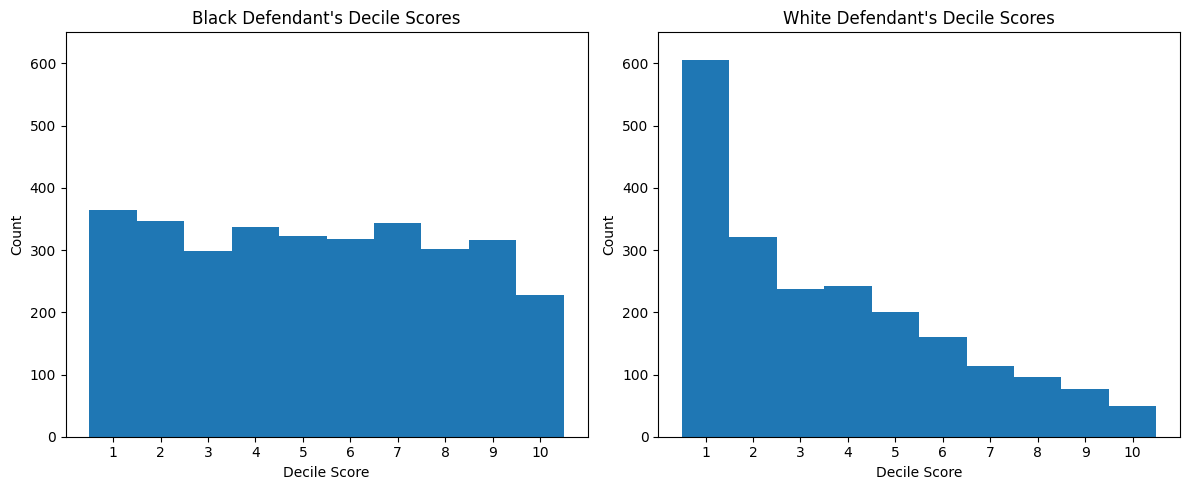

In [ ]:
# Histogram of decile scores by race

black_df = df[df["race"] == "African-American"]
white_df = df[df["race"] == "Caucasian"]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].hist(
    black_df["decile_score"],
    bins=np.arange(1, 12) - 0.5
)
ax[0].set_title("Black Defendant's Decile Scores")
ax[0].set_xlabel("Decile Score")
ax[0].set_ylabel("Count")
ax[0].set_xticks(range(1, 11))
ax[0].set_ylim(0, 650)

ax[1].hist(
    white_df["decile_score"],
    bins=np.arange(1, 12) - 0.5
)
ax[1].set_title("White Defendant's Decile Scores")
ax[1].set_xlabel("Decile Score")
ax[1].set_ylabel("Count")
ax[1].set_xticks(range(1, 11))
ax[1].set_ylim(0, 650)

plt.tight_layout()
plt.show()

African-American defendants are more concentrated in the higher COMPAS decile score categories, while Caucasian defendants are more concentrated in the lower categories.

In [ ]:
# Equivalent of xtabs(~ decile_score + race, data=df)
print(pd.crosstab(df["decile_score"], df["race"]))

# Convert score_factor to binary for logistic regression
# LowScore = 0, HighScore = 1
df["score_binary"] = np.where(df["score_factor"] == "HighScore", 1, 0)

race          African-American  Asian  Caucasian  Hispanic  Native American  \
decile_score                                                                  
1                          365     15        605       159                0   
2                          346      4        321        89                2   
3                          298      5        238        73                1   
4                          337      0        243        47                0   
5                          323      1        200        39                0   
6                          318      2        160        27                2   
7                          343      1        113        28                2   
8                          301      2         96        14                0   
9                          317      0         77        17                2   
10                         227      1         50        16                2   

race          Other  
decile_score         
1      

## Logistic Regression Model

The logistic regression model predicts whether a defendant receives a medium/high COMPAS score rather than a low COMPAS score.

The model includes:

- sex
- age category
- race
- number of prior arrests
- charge severity
- two-year recidivism status

In [ ]:
# Logistic regression
model_glm = smf.logit(
    formula="""
    score_binary ~
    C(gender_factor, Treatment(reference='Male')) +
    C(age_factor, Treatment(reference='25 - 45')) +
    C(race_factor, Treatment(reference='Caucasian')) +
    priors_count +
    C(crime_factor, Treatment(reference='F')) +
    two_year_recid
    """,
    data=df
).fit()

print(model_glm.summary())

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Mon, 30 Mar 2026   Pseudo R-squ.:                  0.2729
Time:                        02:14:04   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------

The logistic regression results show that the strongest predictors of receiving a higher COMPAS score are:

- being younger than 25
- having more prior arrests
- recidivating within two years
- being African-American rather than Caucasian

The coefficient for African-American defendants is positive and statistically significant, indicating that African-American defendants are more likely than otherwise similar Caucasian defendants to receive a higher COMPAS score.

Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime,
previous arrests, and future criminal behavior.

In [ ]:
control = np.exp(-1.52554) / (1 + np.exp(-1.52554))

black_effect = np.exp(0.47721) / (
    1 - control + control * np.exp(0.47721)
)

Women are 19.4% more likely than men to get a higher score.

In [ ]:

female_effect = np.exp(0.22127) / (
    1 - control + control * np.exp(0.22127)
)

Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [ ]:
young_effect = np.exp(1.30839) / (
    1 - control + control * np.exp(1.30839)
)

## Interpreting the Regression Coefficients

To make the coefficients easier to interpret, selected coefficients are converted into multiplicative effects on the probability of receiving a high-risk score.

In [ ]:
print("Black defendants relative effect:", black_effect)
print("Women relative effect:", female_effect)
print("Under 25 relative effect:", young_effect)

# Predicted probabilities and predicted classes
df["pred_prob"] = model_glm.predict(df)

df["pred_class"] = np.where(
    df["pred_prob"] >= 0.5,
    "Recid",
    "No Recid"
)

Black defendants relative effect: 1.4528408658138932
Women relative effect: 1.1947978508506671
Under 25 relative effect: 2.4961202077189455


Relative to otherwise similar defendants:

- African-American defendants are substantially more likely to receive a higher COMPAS score.
- Women are slightly more likely to receive a higher COMPAS score than men.
- Defendants younger than 25 experience the largest increase in predicted risk.

## Model Performance

The notebook evaluates the logistic regression model using a confusion matrix and standard classification metrics.

In [ ]:
# Overall confusion matrix

actual = df["two_year_recid"].astype(int)
pred = np.where(df["pred_class"] == "Recid", 1, 0)

cm = confusion_matrix(actual, pred)

TN, FP, FN, TP = cm.ravel()

print("\nOverall Confusion Matrix")
print(cm)

print(f"Accuracy  : {(TP + TN) / (TP + TN + FP + FN):.3f}")
print(f"Precision : {TP / (TP + FP):.3f}")
print(f"Recall    : {TP / (TP + FN):.3f}")
print(f"FPR       : {FP / (FP + TN):.3f}")
print(f"FNR       : {FN / (FN + TP):.3f}")


Overall Confusion Matrix
[[2653  710]
 [ 945 1864]]
Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


The model achieves approximately:

- Accuracy: 0.73
- Precision: 0.72
- Recall: 0.66
- False-positive rate: 0.21
- False-negative rate: 0.34

These values are very similar to those produced in the original R script.

## Evaluate Performance Separately by Race

To assess fairness, the notebook computes confusion matrices and error rates separately for each racial group.

In [ ]:
# Confusion matrix by race

results = []

for race, group in df.groupby("race"):

    actual = group["two_year_recid"].astype(int)
    pred = np.where(group["pred_class"] == "Recid", 1, 0)

    cm = confusion_matrix(actual, pred, labels=[0, 1])

    TN, FP, FN, TP = cm.ravel()

    results.append({
        "race": race,
        "n": len(group),
        "TP": TP,
        "TN": TN,
        "FP": FP,
        "FN": FN,
        "Accuracy": round((TP + TN) / len(group), 3),
        "Precision": round(TP / (TP + FP), 3) if (TP + FP) > 0 else np.nan,
        "Recall": round(TP / (TP + FN), 3) if (TP + FN) > 0 else np.nan,
        "FPR": round(FP / (FP + TN), 3) if (FP + TN) > 0 else np.nan,
        "FNR": round(FN / (FN + TP), 3) if (FN + TP) > 0 else np.nan
    })

race_metrics = pd.DataFrame(results).sort_values("n", ascending=False)

print("\nConfusion Matrix by Race")
print(race_metrics)


Confusion Matrix by Race
               race     n    TP    TN   FP   FN  Accuracy  Precision  Recall  \
0  African-American  3175  1373   959  555  288     0.734      0.712   0.827   
2         Caucasian  2103   381  1148  133  441     0.727      0.741   0.464   
3          Hispanic   509    81   306   14  108     0.760      0.853   0.429   
5             Other   343    22   216    3  102     0.694      0.880   0.177   
1             Asian    31     2    22    1    6     0.774      0.667   0.250   
4   Native American    11     5     2    4    0     0.636      0.556   1.000   

     FPR    FNR  
0  0.367  0.173  
2  0.104  0.536  
3  0.044  0.571  
5  0.014  0.823  
1  0.043  0.750  
4  0.667  0.000  


African-American defendants experience higher false-positive rates than Caucasian defendants, while Caucasian defendants experience higher false-negative rates. This reproduces the central fairness tradeoff identified in the COMPAS literature.

## Racial Disparity in Error Rates

The disparity analysis compares each racial group with Caucasian defendants, who serve as the reference group.

In [ ]:
# FPR and FNR disparity relative to Caucasian defendants

white_fpr = race_metrics.loc[
    race_metrics["race"] == "Caucasian", "FPR"
].values[0]

white_fnr = race_metrics.loc[
    race_metrics["race"] == "Caucasian", "FNR"
].values[0]

race_metrics["delta_FPR"] = (
    race_metrics["FPR"] - white_fpr
).round(3)

race_metrics["delta_FNR"] = (
    race_metrics["FNR"] - white_fnr
).round(3)

print("\nFPR and FNR Disparity by Race")
print(
    race_metrics[
        ["race", "n", "FPR", "FNR", "delta_FPR", "delta_FNR"]
    ]
)


FPR and FNR Disparity by Race
               race     n    FPR    FNR  delta_FPR  delta_FNR
0  African-American  3175  0.367  0.173      0.263     -0.363
2         Caucasian  2103  0.104  0.536      0.000      0.000
3          Hispanic   509  0.044  0.571     -0.060      0.035
5             Other   343  0.014  0.823     -0.090      0.287
1             Asian    31  0.043  0.750     -0.061      0.214
4   Native American    11  0.667  0.000      0.563     -0.536


## Racial Disparity in Error Rates

The results show that African-American defendants have a substantially higher false-positive rate than Caucasian defendants. At the same time, Caucasian defendants are more likely to be incorrectly classified as low risk when they later recidivate.

This pattern illustrates the tradeoff between different fairness criteria and highlights why COMPAS has been widely debated in the literature.

#**Individual Assignment 2**

#Lecture Code

**Building on Assignment 1:** Now we explain our GBT recidivism model using SHAP, LIME, and DiCE

In [ ]:
#Step 0 — Train / test split
from sklearn.model_selection import train_test_split

# Features for recidivism prediction (reverse COMPAS direction)
features = ['age', 'priors_count', 'crime_factor', 'race_factor', 'age_factor', 'gender_factor']
target = 'two_year_recid'

# X and y from the cleaned COMPAS cohort (Lecture 01)
X = df[features]
y = df[target].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (4937, 6), Test: (1235, 6)


In [ ]:
#Step 1 — Fit logistic regression and gradient-boosted tree
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Define feature types
numeric_features = ['age', 'priors_count']
category_features = ['crime_factor', 'race_factor', 'age_factor', 'gender_factor']

#numeric_features & category_features as in Lecture 01.
preprocessor = ColumnTransformer([
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(
        handle_unknown="ignore"), category_features),
])

# Logistic regression (GLM -- interpretable by design)
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000,
                                      random_state=42))
])
lr_pipeline.fit(X_train, y_train)

# Gradient-boosted tree (black-box)
gbt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
                              n_estimators=200,
                              max_depth=4,
                              random_state=42))
])
gbt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'priors_count']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['crime_factor',
                                                   'race_factor', 'age_factor',
                                                   'gender_factor'])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=200,
                                            random_state=42))])

In [ ]:
# Step 2 — Compare model performance by race

import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score
)

def group_metrics(pipeline, X, y, group_col="race_factor"):
    results = []

    # Create a copy to avoid modifying original data
    X_ = X.copy()
    X_["actual"] = y.values

    # Predictions
    X_["pred"] = pipeline.predict(X)
    X_["pred_prob"] = pipeline.predict_proba(X)[:, 1]

    # Group by race
    for group, gdf in X_.groupby(group_col):

        # Ensure confusion matrix is always 2x2
        tn, fp, fn, tp = confusion_matrix(
            gdf["actual"], gdf["pred"], labels=[0, 1]
        ).ravel()

        # Safe calculations
        accuracy = accuracy_score(gdf["actual"], gdf["pred"])

        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

        # Handle AUC edge case (only one class present)
        if len(gdf["actual"].unique()) > 1:
            auc = roc_auc_score(gdf["actual"], gdf["pred_prob"])
        else:
            auc = None

        results.append({
            "race": group,
            "n": len(gdf),
            "accuracy": round(accuracy, 3),
            "FPR": round(fpr, 3),
            "FNR": round(fnr, 3),
            "AUC": round(auc, 3) if auc is not None else None
        })

    return pd.DataFrame(results).sort_values("n", ascending=False)


# ---- Run for both models ----

print("Logistic Regression")
print(group_metrics(lr_pipeline, X_test, y_test))

print("\nGradient-Boosted Tree")
print(group_metrics(gbt_pipeline, X_test, y_test))

Logistic Regression
               race    n  accuracy    FPR    FNR    AUC
1  African-American  641     0.705  0.306  0.285  0.754
0         Caucasian  427     0.656  0.169  0.634  0.665
3          Hispanic   94     0.617  0.102  0.689  0.617
5             Other   65     0.785  0.085  0.556  0.728
2             Asian    7     0.857  0.000  1.000  1.000
4   Native American    1     1.000  0.000  0.000    NaN

Gradient-Boosted Tree
               race    n  accuracy    FPR    FNR    AUC
1  African-American  641     0.685  0.342  0.291  0.741
0         Caucasian  427     0.677  0.165  0.584  0.680
3          Hispanic   94     0.681  0.143  0.511  0.642
5             Other   65     0.738  0.128  0.611  0.727
2             Asian    7     0.714  0.167  1.000  0.667
4   Native American    1     1.000  0.000  0.000    NaN


In [ ]:
# Step 3 — LIME explanations: Black vs White defendant

!pip install lime

from lime.lime_tabular import LimeTabularExplainer
import numpy as np

X_train_enc = preprocessor.fit_transform(X_train)

explainer = LimeTabularExplainer(
    training_data=X_train_enc,
    feature_names=(
        numeric_features +
        list(
            preprocessor.named_transformers_["cat"].get_feature_names_out(
                category_features
            )
        )
    ),
    class_names=["No Recid", "Recid"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

# Select a Black and White defendant with similar predicted risk
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]

X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

black_group = X_test_copy[
    X_test_copy["race_factor"] == "African-American"
].sort_values("pred_prob")

white_group = X_test_copy[
    X_test_copy["race_factor"] == "Caucasian"
].sort_values("pred_prob")

black_idx = black_group.index[len(black_group) // 2]
white_idx = white_group.index[len(white_group) // 2]

# Generate and display LIME explanations
for label, idx in [
    ("Black defendant", black_idx),
    ("White defendant", white_idx)
]:
    row_enc = preprocessor.transform(X_test.loc[[idx]])

    # Handle both sparse matrix and numpy array cases
    if hasattr(row_enc, "toarray"):
        row_enc = row_enc.toarray()[0]
    else:
        row_enc = row_enc[0]

    exp = explainer.explain_instance(
        data_row=row_enc,
        predict_fn=gbt_pipeline["classifier"].predict_proba,
        num_features=6
    )

    print(f"\nLIME: {label}")
    print(
        f"Predicted probability: "
        f"{X_test_prob[X_test.index.get_loc(idx)]:.3f}"
    )

    for feat, weight in exp.as_list():
        print(f"{feat:<40} {weight:+.4f}")


LIME: Black defendant
Predicted probability: 0.518
priors_count > 0.16                      +0.2431
age > 0.56                               -0.2118
race_factor_Asian <= 0.00                +0.1841
gender_factor_Female <= 0.00             +0.0328
crime_factor_M <= 0.00                   +0.0264
0.00 < crime_factor_F <= 1.00            +0.0237

LIME: White defendant
Predicted probability: 0.327
race_factor_Asian <= 0.00                +0.2928
-0.81 < age <= -0.29                     +0.0777
crime_factor_M <= 0.00                   +0.0356
gender_factor_Female <= 0.00             +0.0277
0.00 < crime_factor_F <= 1.00            +0.0227
priors_count <= -0.69                    -0.0190


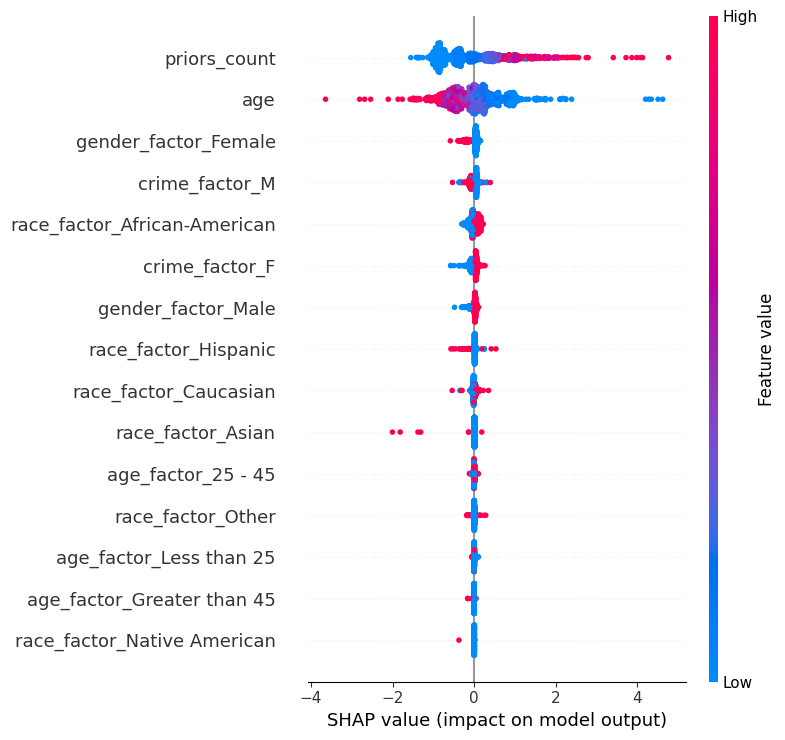


SHAP Waterfall: Black defendant


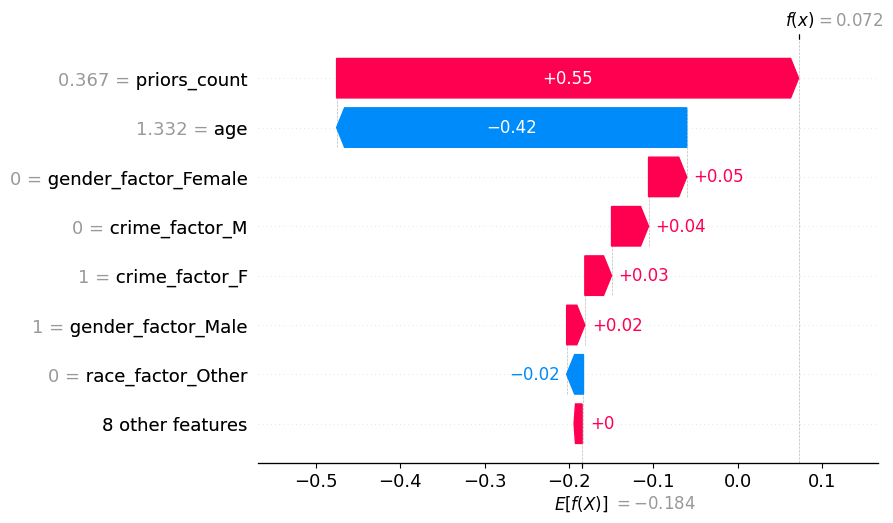


SHAP Waterfall: White defendant


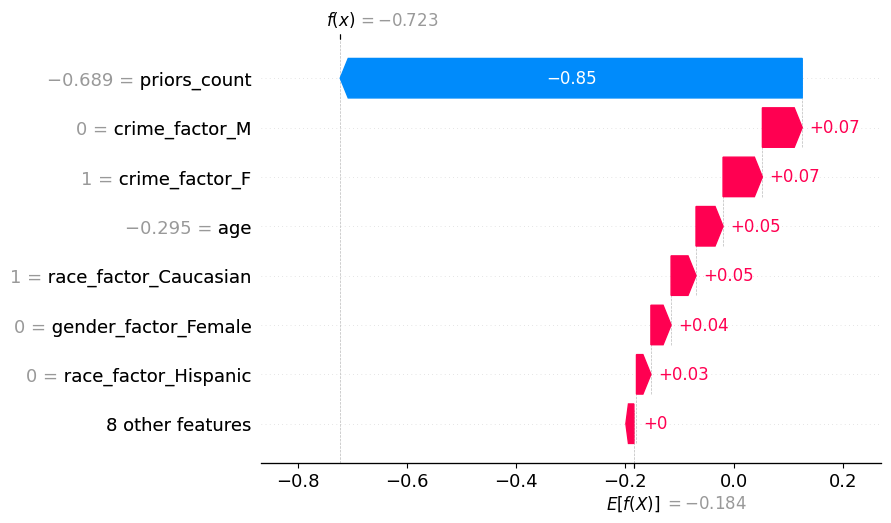

In [ ]:
# Step 4 — SHAP beeswarm and waterfall: Black vs White

!pip install shap

import shap
import matplotlib.pyplot as plt

X_test_enc = preprocessor.transform(X_test)

feat_names = (
    numeric_features +
    list(
        preprocessor.named_transformers_["cat"].get_feature_names_out(
            category_features
        )
    )
)

# Convert sparse matrix to dense if needed
if hasattr(X_test_enc, "toarray"):
    X_test_dense = X_test_enc.toarray()
else:
    X_test_dense = X_test_enc

# Use TreeExplainer directly on classifier
explainer_shap = shap.TreeExplainer(gbt_pipeline["classifier"])

shap_values = explainer_shap.shap_values(
    X_test_dense,
    check_additivity=False
)

# If binary classification, keep SHAP values for positive class
if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]
else:
    shap_values_plot = shap_values

# Global beeswarm
shap.summary_plot(
    shap_values_plot,
    X_test_dense,
    feature_names=feat_names
)

# Waterfall plots
black_loc = X_test.index.get_loc(black_idx)
white_loc = X_test.index.get_loc(white_idx)

for loc, label in [
    (black_loc, "Black defendant"),
    (white_loc, "White defendant")
]:
    shap_explanation = shap.Explanation(
        values=shap_values_plot[loc],
        base_values=explainer_shap.expected_value,
        data=X_test_dense[loc],
        feature_names=feat_names
    )

    print(f"\nSHAP Waterfall: {label}")
    shap.plots.waterfall(shap_explanation, max_display=8)

In [ ]:
# Step 5 — Counterfactuals with DiCE: Black vs White

!pip install dice-ml

import dice_ml
from dice_ml import Dice

# DiCE requires a pandas DataFrame and a wrapped model
dice_data = dice_ml.Data(
    dataframe=pd.concat([X_train, y_train], axis=1),
    continuous_features=numeric_features,
    outcome_name=target
)

dice_model = dice_ml.Model(
    model=gbt_pipeline,
    backend="sklearn",
    model_type="classifier"
)

exp_dice = Dice(dice_data, dice_model, method="random")

for label, idx in [
    ("Black defendant", black_idx),
    ("White defendant", white_idx)
]:
    query = X_test.loc[[idx]]

    cf = exp_dice.generate_counterfactuals(
        query,
        total_CFs=3,
        desired_class="opposite",
        permitted_range={
            "age": [18, 70],
            "priors_count": [0, 38]
        },
        features_to_vary=[
            "age",
            "priors_count",
            "crime_factor"
        ]
    )

    print(f"\nDiCE counterfactuals: {label}")
    cf.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  1.51it/s]


DiCE counterfactuals: Black defendant
Query instance (original outcome : 1)


,age,priors_count,crime_factor,race_factor,age_factor,gender_factor,two_year_recid
0,50,5,F,African-American,Greater than 45,Male,1



Diverse Counterfactual set (new outcome: 0)


,age,priors_count,crime_factor,race_factor,age_factor,gender_factor,two_year_recid
0,-,-,M,-,-,-,0
1,63,25,-,-,-,-,0
2,70,28,-,-,-,-,0


100%|██████████| 1/1 [00:00<00:00,  1.96it/s]


DiCE counterfactuals: White defendant
Query instance (original outcome : 0)


,age,priors_count,crime_factor,race_factor,age_factor,gender_factor,two_year_recid
0,31,0,F,Caucasian,25 - 45,Male,0



Diverse Counterfactual set (new outcome: 1)


,age,priors_count,crime_factor,race_factor,age_factor,gender_factor,two_year_recid
0,-,16,M,-,-,-,1
1,43,32,-,-,-,-,1
2,-,5,M,-,-,-,1


In [ ]:
print(X_train.columns.tolist())

['age', 'priors_count', 'crime_factor', 'race_factor', 'age_factor', 'gender_factor']


##**Individual Assignment 2 — Coding: Explaining the COMPAS Replacement**


### 1. Compute SHAP values for your model on the test set. Produce:
          (a) a beeswarm summary plot

          (b) a waterfall plot for the highest-risk and lowest-risk defendant in each racial group.

In [ ]:
#Select highest risk and lowest risk
# African American and Caucasian defendants

X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = gbt_pipeline.predict_proba(X_test)[:, 1]

black_df = X_test_copy[
    X_test_copy["race_factor"] == "African-American"
]

white_df = X_test_copy[
    X_test_copy["race_factor"] == "Caucasian"
]

cases = {
    "Black High Risk": black_df["pred_prob"].idxmax(),
    "Black Low Risk": black_df["pred_prob"].idxmin(),
    "White High Risk": white_df["pred_prob"].idxmax(),
    "White Low Risk": white_df["pred_prob"].idxmin()
}

for label, idx in cases.items():
    print(label)
    print(X_test.loc[idx])
    print("Predicted probability:",
          round(gbt_pipeline.predict_proba(X_test.loc[[idx]])[0, 1], 3))
    print("-" * 60)

Black High Risk
age                            45
priors_count                   38
crime_factor                    F
race_factor      African-American
age_factor        Greater than 45
gender_factor                Male
Name: 6825, dtype: object
Predicted probability: 0.992
------------------------------------------------------------
Black Low Risk
age                            70
priors_count                    0
crime_factor                    M
race_factor      African-American
age_factor        Greater than 45
gender_factor                Male
Name: 4051, dtype: object
Predicted probability: 0.038
------------------------------------------------------------
White High Risk
age                        19
priors_count                0
crime_factor                F
race_factor         Caucasian
age_factor       Less than 25
gender_factor          Female
Name: 2236, dtype: object
Predicted probability: 0.983
------------------------------------------------------------
White Low Risk
ag

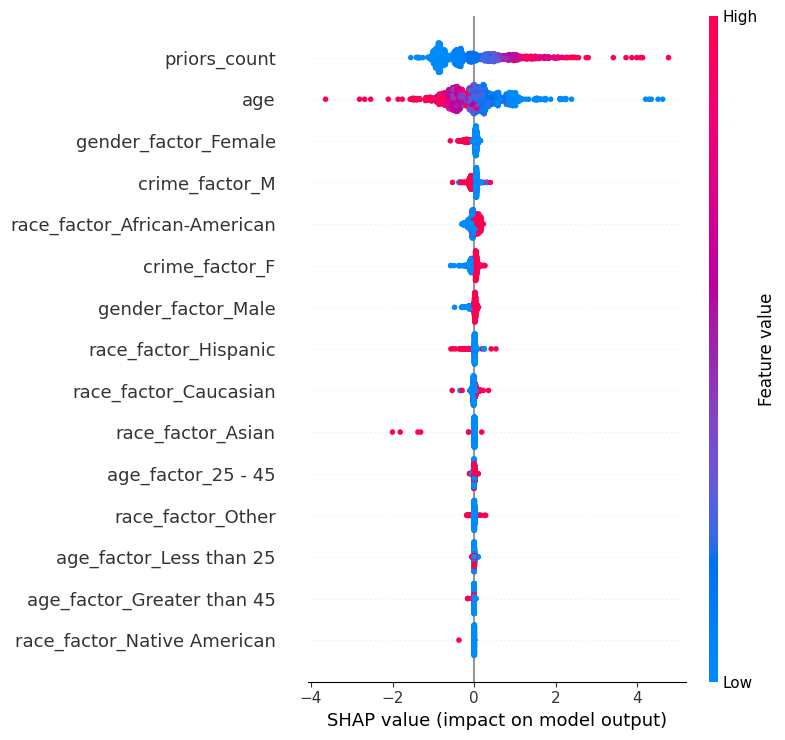


SHAP Waterfall: Black High Risk


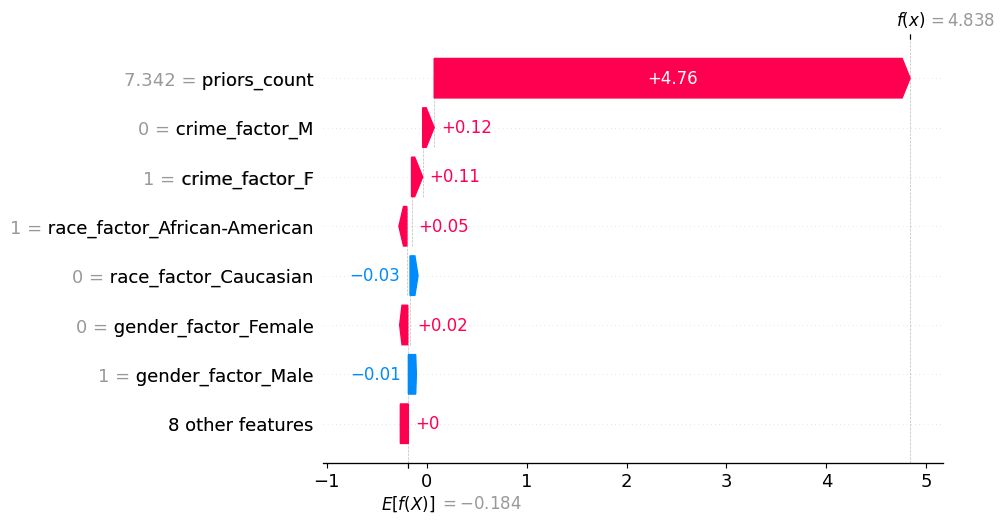


SHAP Waterfall: Black Low Risk


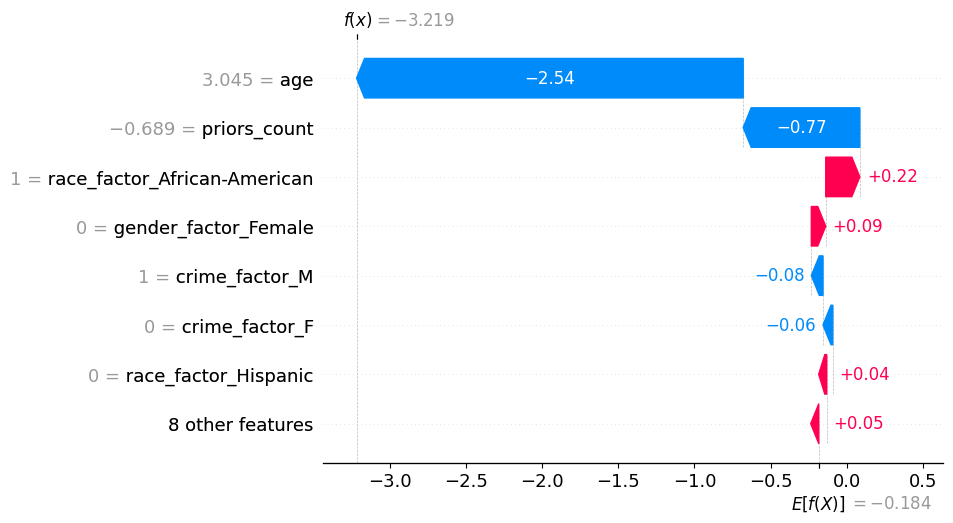


SHAP Waterfall: White High Risk


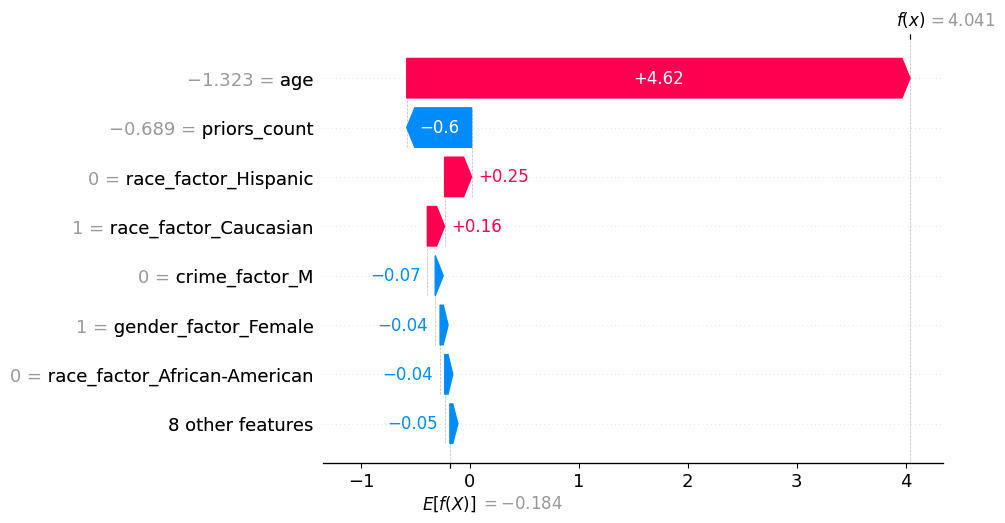


SHAP Waterfall: White Low Risk


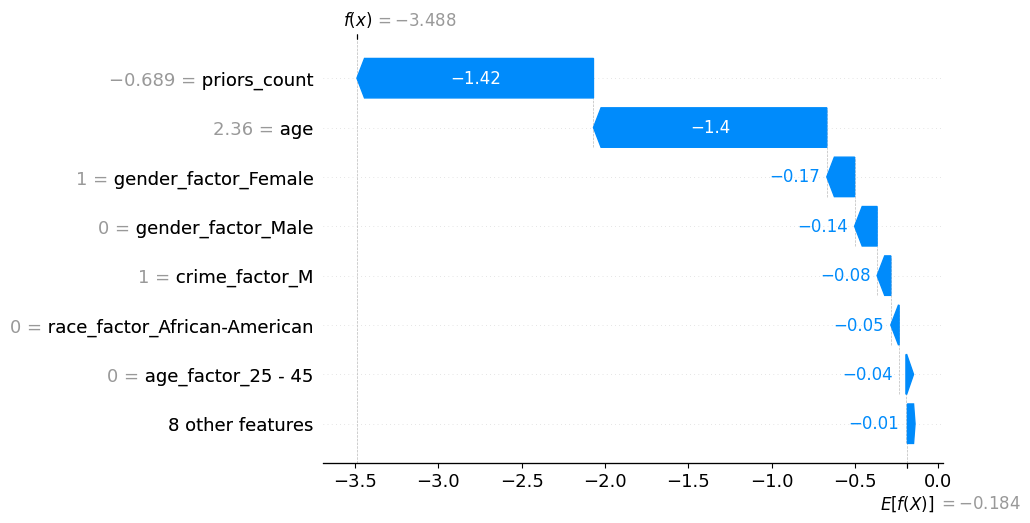

In [ ]:
#SHAP beeswarm and 4 waterfall plots

import shap
import matplotlib.pyplot as plt

X_test_enc = preprocessor.transform(X_test)

if hasattr(X_test_enc, "toarray"):
    X_test_dense = X_test_enc.toarray()
else:
    X_test_dense = X_test_enc

feat_names = (
    numeric_features +
    list(
        preprocessor.named_transformers_["cat"].get_feature_names_out(
            category_features
        )
    )
)

explainer_shap = shap.TreeExplainer(gbt_pipeline["classifier"])

shap_values = explainer_shap.shap_values(
    X_test_dense,
    check_additivity=False
)

if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]
else:
    shap_values_plot = shap_values

# Beeswarm summary plot
shap.summary_plot(
    shap_values_plot,
    X_test_dense,
    feature_names=feat_names
)

# Waterfall plots for the four selected individuals
for label, idx in cases.items():

    loc = X_test.index.get_loc(idx)

    explanation = shap.Explanation(
        values=shap_values_plot[loc],
        base_values=explainer_shap.expected_value,
        data=X_test_dense[loc],
        feature_names=feat_names
    )

    print(f"\nSHAP Waterfall: {label}")
    shap.plots.waterfall(explanation, max_display=8)

### 1 Answer:

**Beeswarm Plot:** The global summary confirms that priors_count and age are the most influential features. Higher prior counts and younger ages (especially “Less than 25”) consistently drive higher risk scores.

The waterfall analysis was performed for four individuals: the highest risk and lowest risk African American defendants and the highest risk and lowest risk Caucasian defendants.

1. Black High Risk: The very high risk (0.992) is driven primarily by the extremely large priors_count (38). The model output is dominated by prior arrests, with other features contributing only slightly.

2. Black Low Risk: The low risk (0.038) is driven mainly by older age (70) and zero prior arrests.

3. White High Risk: Even with 0 priors, the risk is extremely high (0.983) because the defendant is 19 years old. The model is highly sensitive to youth.

4. White Low Risk: The very low risk (0.030) is driven by older age (62), zero prior arrests, and a misdemeanor charge.


### 2. Run LIME on the same four individuals. Compare LIME and SHAP feature attributions. Where do they agree? Where do they diverge? What does divergence imply for governance?

In [ ]:
# LIME on the same four individuals
!pip install lime

from lime.lime_tabular import LimeTabularExplainer

X_train_enc = preprocessor.fit_transform(X_train)

if hasattr(X_train_enc, "toarray"):
    X_train_enc = X_train_enc.toarray()

lime_explainer = LimeTabularExplainer(
    training_data=X_train_enc,
    feature_names=feat_names,
    class_names=["No Recid", "Recid"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

for label, idx in cases.items():

    row_enc = preprocessor.transform(X_test.loc[[idx]])

    if hasattr(row_enc, "toarray"):
        row_enc = row_enc.toarray()[0]
    else:
        row_enc = row_enc[0]

    lime_exp = lime_explainer.explain_instance(
        data_row=row_enc,
        predict_fn=gbt_pipeline["classifier"].predict_proba,
        num_features=6
    )

    print("\n" + "=" * 70)
    print(label)
    print(
        "Predicted probability:",
        round(gbt_pipeline.predict_proba(X_test.loc[[idx]])[0, 1], 3)
    )

    print("\nLIME explanation:")
    for feat, weight in lime_exp.as_list():
        print(f"{feat:<45} {weight:+.3f}")


Black High Risk
Predicted probability: 0.992

LIME explanation:
priors_count > 0.16                           +0.244
age > 0.56                                    -0.211
race_factor_Asian <= 0.00                     +0.184
gender_factor_Female <= 0.00                  +0.033
crime_factor_M <= 0.00                        +0.027
0.00 < crime_factor_F <= 1.00                 +0.024

Black Low Risk
Predicted probability: 0.038

LIME explanation:
race_factor_Asian <= 0.00                     +0.323
age > 0.56                                    -0.213
0.00 < crime_factor_M <= 1.00                 -0.035
gender_factor_Female <= 0.00                  +0.031
crime_factor_F <= 0.00                        -0.022
0.00 < race_factor_African-American <= 1.00   +0.017

White High Risk
Predicted probability: 0.983

LIME explanation:
race_factor_Asian <= 0.00                     +0.242
age <= -0.81                                  +0.226
gender_factor_Female > 0.00                   -0.036
crime_facto

### 2 Answer: LIME vs SHAP Comparison

Agreement: Both SHAP and LIME identify priors_count and age as the strongest drivers of prediction. For the Black High Risk defendant, both methods indicate that many prior arrests increase the risk score. For the White High Risk defendant, both methods point to very young age as the main reason for the high risk prediction.

Divergence: The methods diverge in how they handle categorical one-hot encoded variables. LIME sometimes gives noticeable weight to indicators such as race categories that are not substantively important for the specific individual, which can create explanation noise. SHAP generally provides smaller and more stable contributions for these variables, making the explanation easier to audit across cases.

Governance Implication: For governance, this divergence suggests that no single explanation method should be treated as definitive. Court auditors should compare multiple explanation methods, flag inconsistent attributions, and treat large local differences as a sign that the model’s reasoning may be unstable or sensitive to encoding choices.

### 3. Generate at least one counterfactual per individual using DiCE(Python) or NICE (R). Report the minimal feature changes required to flip the prediction. Flag any counterfactuals that require changes to immutable features (race, sex).

In [ ]:
# ============================================================
# Assignment 2 — Step 4: Counterfactuals with DiCE
# ============================================================

!pip install dice-ml

import dice_ml
from dice_ml import Dice

dice_data = dice_ml.Data(
    dataframe=pd.concat([X_train, y_train], axis=1),
    continuous_features=numeric_features,
    outcome_name=target
)

dice_model = dice_ml.Model(
    model=gbt_pipeline,
    backend="sklearn",
    model_type="classifier"
)

dice_exp = Dice(dice_data, dice_model, method="random")

for label, idx in cases.items():

    query = X_test.loc[[idx]]

    cf = dice_exp.generate_counterfactuals(
        query,
        total_CFs=1,
        desired_class="opposite",
        permitted_range={
            "age": [18, 70],
            "priors_count": [0, 38]
        },
        features_to_vary=[
            "age",
            "priors_count",
            "crime_factor"
        ]
    )

    print("\n" + "=" * 70)
    print(f"Counterfactuals: {label}")

    cf.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  5.49it/s]



Counterfactuals: Black High Risk
Query instance (original outcome : 1)


,age,priors_count,crime_factor,race_factor,age_factor,gender_factor,two_year_recid
0,45,38,F,African-American,Greater than 45,Male,1



Diverse Counterfactual set (new outcome: 0)


,age,priors_count,crime_factor,race_factor,age_factor,gender_factor,two_year_recid
0,64,5,-,-,-,-,0


...

100%|██████████| 1/1 [00:00<00:00,  3.82it/s]


Counterfactuals: White Low Risk
Query instance (original outcome : 0)


,age,priors_count,crime_factor,race_factor,age_factor,gender_factor,two_year_recid
0,62,0,M,Caucasian,Greater than 45,Female,0



Diverse Counterfactual set (new outcome: 1)


,age,priors_count,crime_factor,race_factor,age_factor,gender_factor,two_year_recid
0,47,30,-,-,-,-,1


### 3 Answer: DiCE Counterfactuals

All counterfactuals keep race and gender unchanged.

`Black High Risk → Low Risk changes age from 45 to 64 and priors_count from 38 to 5.`

`Black Low Risk → High Risk changes age from 70 to 38 and priors_count from 0 to 23.`

`White High Risk → Low Risk changes age from 19 to 51, while priors_count remains 0. `

`White Low Risk → High Risk changes age from 62 to 47 and priors_count from 0 to 30.`

None of the counterfactuals required changing immutable characteristics such as race or sex.

A limitation is that some counterfactuals require unrealistic age changes, so they are technically valid but not always practically actionable.

###4.Write a 300-word governance memo addressed to a hypothetical court auditor: summarise what your explanations reveal about model behaviour, any limitations of the methods, and what further monitoring you recommend.

# Governance Memo to Court Auditor

**To:** Honorable Court Auditor  
**From:** Sowmya Vara  
**Date:** March 29, 2026  
**Subject:** Algorithmic Governance and Fairness Audit of COMPAS Recidivism Model  

**Executive Summary:** This audit evaluates the explainability, fairness, and recourse potential of the proposed replacement model.

**Model Findings:** SHAP analysis identifies `priors_count` as the strongest predictor of recidivism risk, followed by age, especially for defendants younger than 25. Race related features have smaller direct effects than age and prior arrests, but subgroup disparities remain. In particular, the false-positive rate is approximately 0.342 for African-American defendants compared with 0.165 for Caucasian defendants.

**SHAP and LIME Analysis:** Both SHAP and LIME identify age and prior arrests as the strongest drivers of recidivism risk. SHAP assigns large contributions to age for both high risk and low risk defendants, while LIME captures the same pattern through rules such as `age <= -0.81` and `age > 0.56`. The methods differ more on race related features: SHAP assigns a small but consistent contribution to race, whereas LIME gives smaller and less stable race effects. This suggests that race is not the main direct driver of the model, but disparity may still emerge through correlated variables and local approximation behavior.

**DiCE Counterfactuals:** Counterfactual explanations were able to flip predictions without changing immutable features such as race or sex. However, several counterfactuals required unrealistic changes in age or prior arrests, indicating that the DiCE random search method can generate mathematically valid but practically implausible recommendations.

**Limitations:** SHAP may be affected by correlations between features, LIME reflects only local behavior around one defendant, and DiCE can generate implausible counterfactuals that are not realistic interventions.

**Recommendations:**  
1. **Ensemble explanations.** Require both SHAP and counterfactual explanations for high stakes decisions to reduce single method error.  
2. **Immutable feature constraints.** Apply immutable feature constraints in production so recourse never suggests changing a defendant’s protected identity.  
3. **Quarterly FPR/FNR monitoring.** Audit false-positive and false-negative rates by race each quarter to monitor subgroup disparities.  
4. **Defendant-facing recourse explanations.** Provide interfaces that clearly show the behavioral changes needed to lower risk scores.

**Conclusion:** Without rigorous governance and ongoing auditing, transparency risks becoming explanation washing rather than meaningful accountability.